A `STARNet` workflow can be divided into two stages: STARNet model training and GRN module inference, as well as leveraging the inferred Gene Regulatory Network for downstream tasks(such as Spatial Trajectory Inference, GWAS analysis and drug response analysis).

In this tutorial, we will show how to prepare the necessary data for STARNet training. The data includes paired RNA-ATAC-seq data for the `mouse embryo`. After training, we will utilize the gene and spot embedding for the downstream Gene Regulatory Network (GRN) Inference.

In [1]:
import warnings
import os
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"

import scanpy as sc
import anndata as ad
import STARNet as ST
import pickle

## Stage 1: Model Training and GRN Inference

### Read data

The data used for this tutorial, which is the spatial transcriptome for the mouse embryo file, can be downloaded from the following links: [Links to Data Folder](https://drive.google.com/drive/folders/1obqewcAAvcUi8WOhqomKDo7BO_GncNvP?usp=sharing). Place the data in the same folder as your tutorial code. You can download specific data files or all of them at once.

In [2]:
adata_rna = sc.read_h5ad("Drive/Datasets/Mouse_Embryo/Raw_Data/adata_rna.h5ad")
adata_atac = sc.read_h5ad("Drive/Datasets/Mouse_Embryo/Raw_Data/adata_atac.h5ad")

Here, we used `ST.model.STARNet` to construct a `STARNet object` to train the model. We need to specify the `RNA-seq`, `ATAC-seq` during the model initialization.

In [3]:
starnet_obj = ST.model.STARNet(adata_rna, adata_atac, device='cuda:6')

Then, we use the `preprocess()` function to prepare the transcriptomics data and construct graphs. This single function handles multiple tasks: quality control, selection of highly variable genes/peaks, data normalization, and construction of various graphs (scRNA, scATAC, cell neighbor, and peak2gene).

In [4]:
starnet_obj.preprocess()


Step 1: Data Alignment and Initialization
📄 Data Alignment Results:
   ✓ adata_rna: Dataset shape: 2133 spots × 19930 genes
   ✓ adata_atac: Dataset shape: 2133 spots × 360035 peaks
Converting adata_rna.X to csr_matrix format.
✅ Conversion complete.

Step 2: Processing RNA Data
Filtering genes: min_cells=15
Running RNA Leiden clustering (res=0.2)...

Step 3: Processing ATAC Data
Selecting top 40000 ATAC peak features.
Running ATAC Leiden clustering (res=0.2)...
Final RNA shape: (2133, 15189)
Final ATAC shape: (2133, 40000)

Step 4: Building Heterogeneous HyperGraph
🧬 RNA graph nodes prepared: 15189 genes
🧩 ATAC graph nodes prepared: 40000 peaks
Building Dual-Modality Spot-Spot matrices...
Using 'leiden' clusters from obs.
Constructed dual-modality matrix for K=3.
Constructed dual-modality matrix for K=4.
Constructed dual-modality matrix for K=8.
 ✅ Graph data moved to device: cuda:6


Finally, we train the model for 600 epochs, which is the recommended duration. The outputs—cell embedding and gene embedding—are saved to the obs and uns layers of the AnnData.

In [5]:
starnet_obj.train(epochs=600, eval_every=600)


🔍 Step 1: STARNet Model Initialization and Configuration
📄 Model Parameters:
   ✓ Hidden Dim: 128
   ✓ Output Dim: 128
   ✓ Device: cuda:6
   ✓ SSL Num Neg: 10240


INFO: GPU available: True (cuda), used: True
2026-05-11 03:10:37 - INFO - GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-11 03:10:37 - INFO - TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-05-11 03:10:37 - INFO - 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090 D') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/

Lightning model built with ComplexConv_v4 architecture.

🔍 Step 2: Starting STARNet Training Loop
📄 Training Configuration:
   ✓ Max Epochs           : 600
   ✓ Device               : cuda:6
   ✓ Evaluation Every     : 600 epochs
   ✓ Checkpointing        : True
   ✓ TensorBoard Log Dir  : ./lightning_logs/STARNet/version_8


Epoch 000/600:   0%|          | 0/600 [00:00<?, ?epoch/s]

📊 Epoch Summary: epoch=1/600, best_total_loss=6.4427
📊 Epoch Summary: epoch=600/600, best_total_loss=0.6776
Evaluating clustering using representation 'cell_embedding'...


INFO: `Trainer.fit` stopped: `max_epochs=600` reached.
2026-05-11 03:12:42 - INFO - `Trainer.fit` stopped: `max_epochs=600` reached.


📊 Training Summary:
   ✓ Completed Epochs     : 600
   ✓ Best Total Loss      : 0.6776
 ✅ Epoch-level training visualization finished.
✅ Training finished!
   ✓ TensorBoard logs saved to: ./lightning_logs/STARNet/version_8
   ✓ Checkpoints saved to: ./lightning_logs/checkpoints


Plotting clustering results...


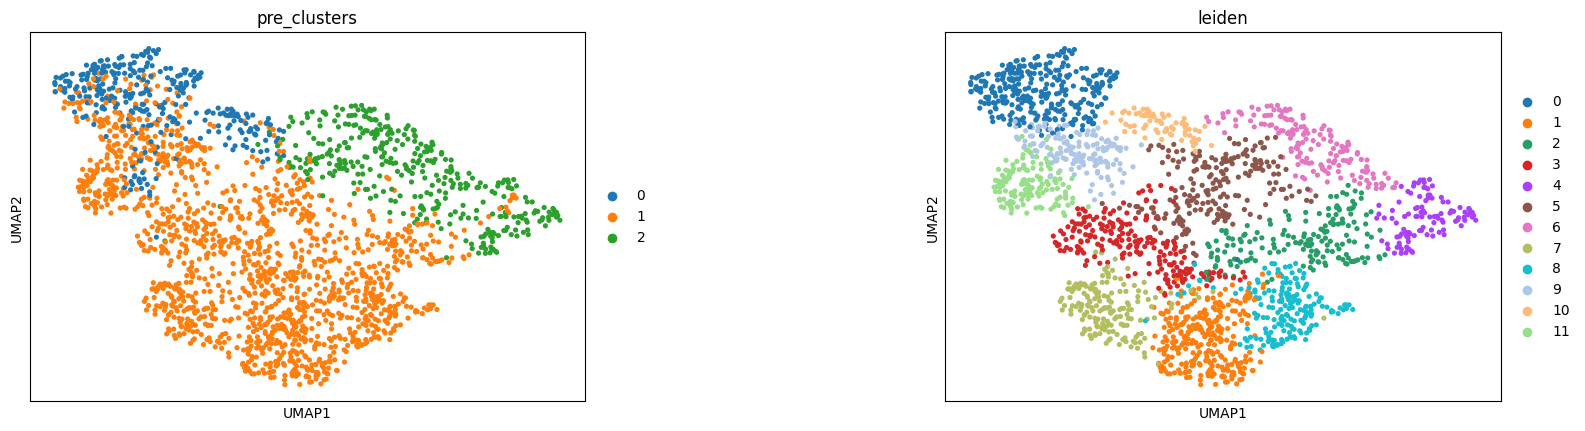

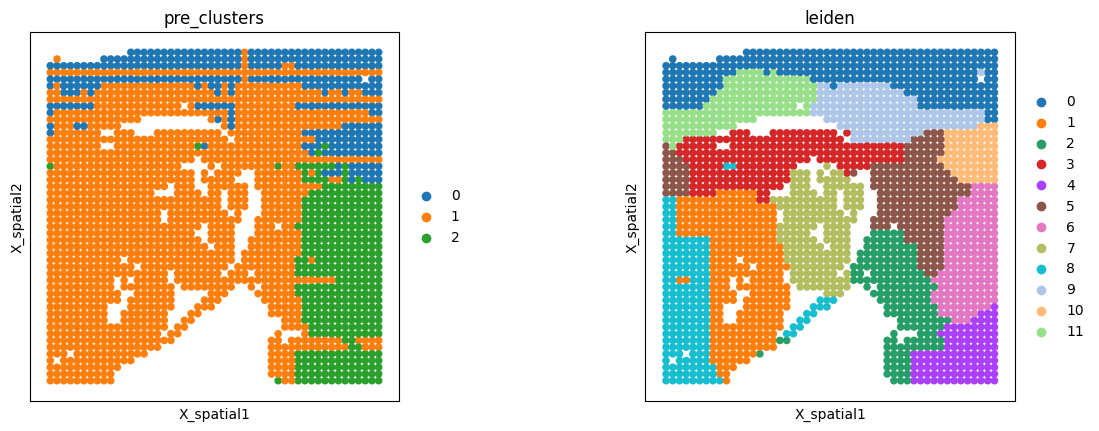

In [6]:
starnet_obj.plot_clustering_results(rep_name='cell_embedding', spot_size=50)

The AnnData for RNA-seq is shown below. We save it for later usage.

In [7]:
print(f'RNA data after training: {starnet_obj.adata_rna}')
starnet_obj.adata_rna.write_h5ad("Drive/Datasets/Mouse_Embryo/Process_Data/adata_rna_trained.h5ad")

RNA data after training: AnnData object with n_obs × n_vars = 2133 × 15189
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'pre_clusters'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'gene_embedding', 'pre_clusters_colors', 'leiden_colors'
    obsm: 'X_spatial', 'X_pca', 'cell_embedding', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


### Load multi-omics data

Here we provide two data options for the GRN Inference: one is to directly use the data you trained in stage 1, and the other is to load from your pre-trained dataset.

In [8]:
# Load data from the trained model or from a saved state

# optional
# adata_rna = starnet_obj.adata_rna
# adata_atac = starnet_obj.adata_atac

adata_rna = sc.read_h5ad('Drive/Datasets/Mouse_Embryo/Process_Data/adata_rna_trained.h5ad')
adata_rna_raw = sc.read_h5ad("Drive/Datasets/Mouse_Embryo/Raw_Data/adata_rna.h5ad")
adata_atac = sc.read_h5ad("Drive/Datasets/Mouse_Embryo/Raw_Data/adata_atac.h5ad")

We continue to process the RNA-ATAC-seq data and add the raw counts into the `count` layer, as the later GRN calculation is based on the raw count data.

RNA data info:
AnnData object with n_obs × n_vars = 2133 × 15189
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'pre_clusters'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'gene_embedding', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'pre_clusters_colors', 'umap'
    obsm: 'X_pca', 'X_spatial', 'X_umap', 'cell_embedding'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
ATAC data info:
AnnData object with n_obs × n_vars = 2133 × 360035
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'Sample'
    obsm: 'X_spatial'
    layers: 'counts'


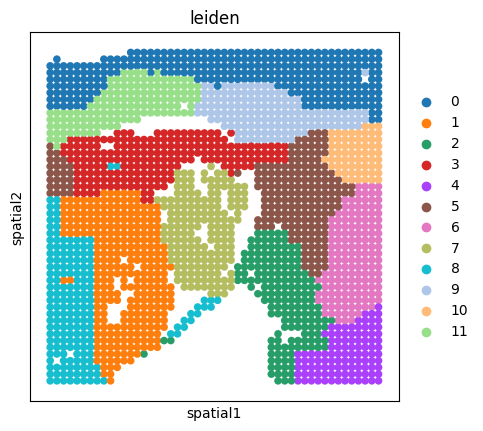

In [9]:
gene_embedding = ad.AnnData(adata_rna.uns['gene_embedding'])
gene_embedding.obs_names = adata_rna.var_names.tolist()
adata_rna.uns['gene_embedding'] = gene_embedding

adata_rna.layers['counts'] = adata_rna_raw[:,adata_rna.var_names].X
adata_atac.layers['counts'] = adata_atac.X

# Preprocess
adata_rna.obs_names = [obs_names.split('-')[0] for obs_names in adata_rna.obs_names]
adata_atac.obs_names = [obs_names.split('-')[0] for obs_names in adata_atac.obs_names]

print(f'RNA data info:\n{adata_rna}')
print(f'ATAC data info:\n{adata_atac}')

sc.pl.spatial(adata_rna,color='leiden',spot_size=50)

### Load Genomic Files and Inference

With all the data properly prepared, we can now load `genomic data` and begin inferring GRN from multiomics data. The `use_rep` parameter specifies which cell embedding to use. The `pvalue_regulatory` parameter filters out genes with significance greater than 0.2, while `moranI_threshold` ensures that only TFs with Moran's I values less than 0.01 are considered spatially specific and used for subsequent analysis.

In [10]:
genomic_data_pathway = 'Drive/Datasets/Reference/mouse_vM25'
adata_rna = ST.grn.infer_grn_from_multiomics(adata_rna,
                                             adata_atac,
                                             genomic_data_pathway,
                                             use_rep='cell_embedding',
                                             pvalue_regulatory=0.2,
                                             moranI_threshold=0.01,
                                             n_jobs=5)


🧬 Starting Spatially Specific GRN Inference Pipeline in STARNet

🔍 Step 1: Identifying Genomic Reference Files
📄 Target Directory: Drive/Datasets/Reference/mouse_vM25
✅ Genomic files identified and validated.
📄 File Discovery Results:
   ✓ Motif File        : cisBP_mouse.meme
   ✓ Genome Fasta      : gencode_vM25_GRCm38.fa
   ✓ Annotation (GFF)  : gencode_vM25_GRCm38.gff3
   ✓ Annotation (GTF)  : gencode_vM25.chr_patch_hapl_scaff.annotation.gtf
 ✅ Reference genome and annotation paths successfully loaded.

🔍 Step 2: Peak GC Content Analysis
 ⚙️ Calculating GC proportion for peaks of spatial ATAC-seq data...

🔍 Step 3: Spatially Specific Transcription Factor Identification
 ⚙️ Identifying TFs with significant spatial patterns (Moran's I > 0.01)...
   ✓ Identify spatially-variable expressed TFs: 327

🔍 Step 4: Genomic Data Alignment and Formatting
✅ Genomic data preparation successful.
📄 Processed Stats:
   ✓ RNA spots/genes  : 2133 × 14513
   ✓ ATAC spots/peaks : 2133 × 360012
   ✓ Ali

  0%|          | 0/2133 [00:00<?, ?it/s]

  0%|          | 0/2133 [00:00<?, ?it/s]

  0%|          | 0/2133 [00:00<?, ?it/s]

 ⚙️ Building kernel on cell_embedding...


...

   ✓ Generated 28 metacells.

🔍 Step 7: GRN Filtering (Stage1)
 ⚙️  Calculating correlations for 162500 interactions...
 📄 Processed Stats:
   ✓ Threshold                   : >0.2
   ✓ Initial TF-target Pairs     : 162500
   ✓ Passed TF-target Pairs    : 77111
   ✓ Removal TF-target Rate      : 52.55%
✅ Correlation filtering complete.
 ⚙️ Mapping peaks to genes (100kb around gene body)...
 📄 Processed Stats:
   ✓ Expand Range    : +/- 100,000 bp
   ✓ Initial Pairs   : 77111
   ✓ Validated Pairs : 76953
   ✓ Removal Rate    : 0.20%
✅ Peak filtering complete.

 ⚙️ Step 8: GRN Filtering using Peak-to-Gene Links (Stage2)
Loading transcripts per gene...
Preparing matrices for gene-peak associations


100%|██████████| 11426/11426 [22:59<00:00,  8.28it/s]


Computing peak-gene correlations


100%|██████████| 11426/11426 [2:09:06<00:00,  1.48it/s] 


 📄 Processed Stats:
    ✓ Initial Peak-to-Gene Links     : 638,235
    ✓ Significant Peak-to-Gene Links : 147,684
    ✓ Removal Rate                  : 76.86%
✅ Peak-to-Gene filtering complete.

🔍 Step 9: Parallel Motif Scanning
 ⚙️ Identify the motif corresponding to specific transcription factors...

📊 Finally Spaitally Specific GRN Inference Results:
 📊 Final Network Summary:
   ✓ Total Target Genes          : 9,434
   ✓ Total Regulatory Peaks      : 129,661
   ✓ Total TF-Target Interactions: 50,171
 ✅ Network added to .uns['grn_df'] and regulatory peaks to .uns['regulatory_peaks']


Now, we need to extract the peak-gene association via the `Gene Transfer Format file`, which can be downloaded from the following links: [To be implemented]. This extraction is necessary because transcription factors (TFs) can bind to spatially specific cis-regulatory elements (cCREs) of DNA and activate target gene expression in spatially specific Gene Regulatory Networks (GRNs).

In [11]:
gtf_pathway = 'Drive/Datasets/Reference/mouse_vM25/gencode_vM25.chr_patch_hapl_scaff.annotation.gtf.gz'
peak2gene = ST.pp.extract_peak_gene_associations(adata_rna,gtf_file=gtf_pathway)
peak2gene.to_csv('Drive/Datasets/Mouse_Embryo/Process_Data/peak2gene.links', sep="\t", index=False)


🔗 Extracting Peak-Gene Associations for Visualization
 ⚙️ Loading GTF and aligning gene coordinates...
 ⚙️ Aggregating Peak-to-Gene links from .uns['Peak2Gene']...


 ⚙️ Parsing genomic coordinates...
 ⚙️ Calculating scores and formatting...
 📊 Association Extraction Summary:
   ✓ Total Raw Links      : 147,684
   ✓ Self-loops Removed   : 10
   ✓ Final Associations   : 147,674
 ✅ Formatting complete.


After obtaining the GRN and peak-gene links information, we can score each GRN and TF module to quantify the strength of a TF's influence on its target genes. This regulatory score serves two primary purposes. First, it enables clear GRN visualization by filtering for the most significant interactions. Second, in cell reprogramming analysis, these scores function as edge weights in the constructed GRN, which is then provided as a key input to the PriciCE model.

In [12]:
# Perform permutation test on all gene regulatory networks
adata_rna = ST.pp.score_all_grn(adata_rna,n_jobs=5)

# Calculate the TF module using various clustering methods and perform cauchy combination tests
adata_rna = ST.pp.score_TF_module(adata_rna,
                                  clustering_method='leiden',
                                  resolution = 2,
                                  groupby='leiden',n_jobs=5)


🧬 Calculating GRN Significance via Permutation Test
 ⚙️ Starting parallel scoring for 325 GRNs...


Scoring GRNs: 100%|██████████| 325/325 [15:46<00:00,  2.91s/it]


 ✅ Scoring complete! Results stored in:
  Full GRN score AnnData: added to .uns['grn']['adata_nlog10_pval']

🧬 TF Module Analysis: Clustering & Significance
 ⚙️ Preprocessing and running leiden clustering...
 ✅ Leiden clustering finished: 16 clusters found.
 ⚙️ Scoring 16 TF modules in parallel...


100%|██████████| 16/16 [00:57<00:00,  3.61s/it]


--------------------------------------------------
 ✨ All tasks completed successfully!
  1. TF Gene Lists:       added to .uns['TF_module']['TF_list']
  2. Target Gene Lists:   added to .uns['TF_module']['target_gene_list']
  3. Score AnnData:       added to .uns['TF_module']['nlog10_pval_ad']
  4. Cauchy Results:      added to .uns['TF_module']['cauchy_combination_test']



We can save the calculated and scored GRN and TF modules in `AnnData` and `pickle` formats, respectively, for later downstream analysis.

In [13]:
adata_rna.uns['grn']['adata_nlog10_pval'].T.write_h5ad("Drive/Datasets/Mouse_Embryo/Process_Data/mouse_embryo_grn_nlog10_pval.adata")

with open('Drive/Datasets/Mouse_Embryo/Process_Data/TF_module_30.pkl', 'wb') as f:
	pickle.dump(adata_rna.uns['TF_module'], f)

with open('Drive/Datasets/Mouse_Embryo/Process_Data/TF_module_leiden_2.pkl', 'wb') as f:
	pickle.dump(adata_rna.uns['TF_module'], f)

### Visualization of GRN modules

The following cell visualizes the GRN module in spatial coordinates, which aligns well with specific areas of the mouse brain.

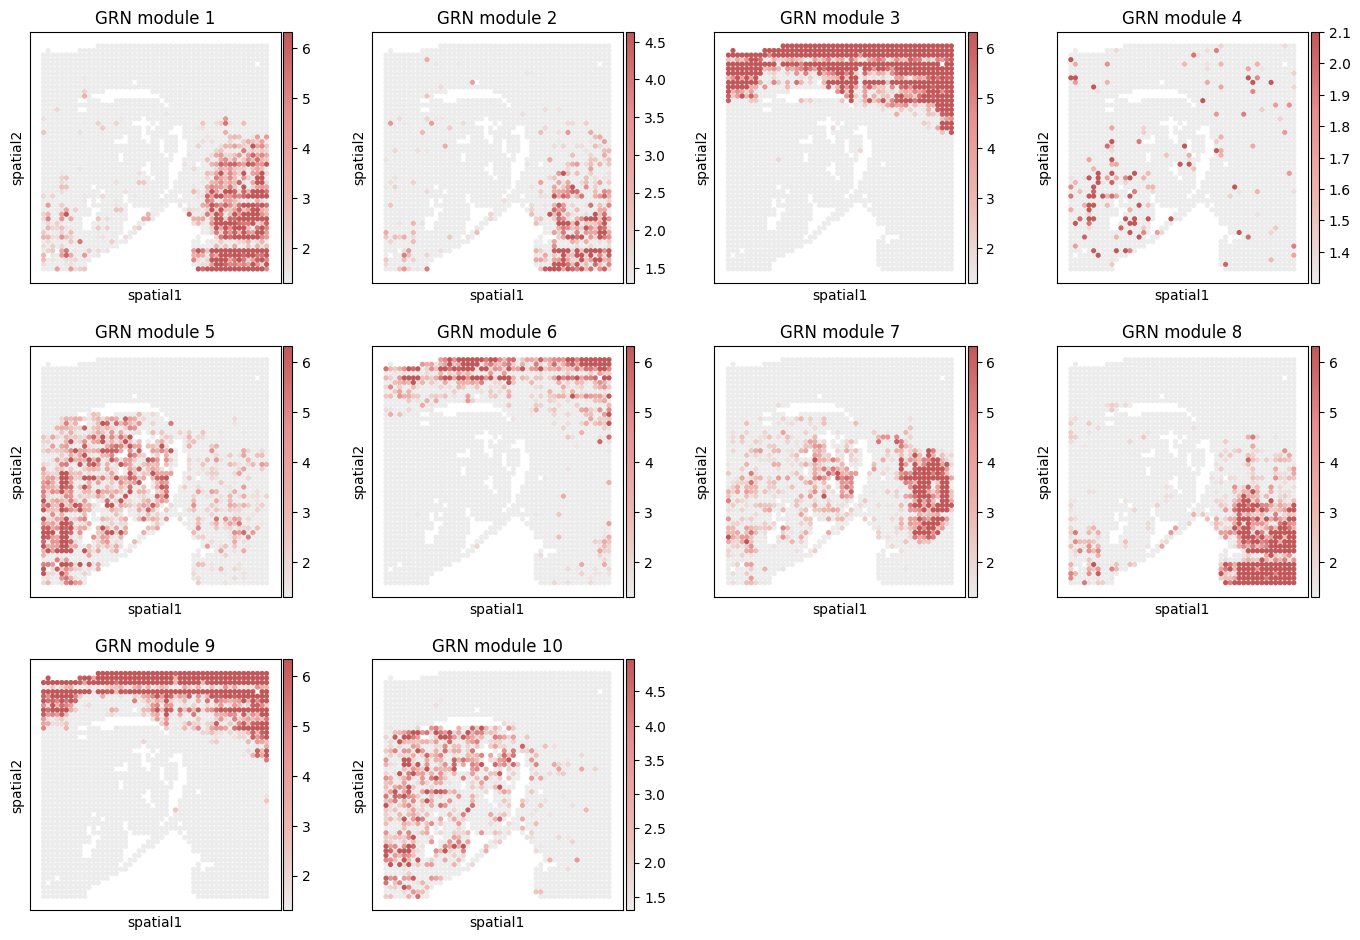

In [15]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import anndata as ad

nlog10_pval_df = adata_rna.uns['TF_module']['nlog10_pval_df']
nlog10_pval_df = nlog10_pval_df.loc[:,[str(i) for i in range(10)]]
nlog10_pval_ad = ad.AnnData(nlog10_pval_df)
nlog10_pval_ad.obsm['spatial'] = adata_rna[nlog10_pval_ad.obs_names,:].obsm['spatial']
nlog10_pval_ad.var_names = ['GRN module ' + str(int(GRM)+1) for GRM in nlog10_pval_ad.var_names]

def get_cmap_seg(colors,N=256):
        from matplotlib.colors import LinearSegmentedColormap
        # Define the colors for the gradient
        colors = np.array(colors) / 255.0
        # Create a colormap from the list of colors
        cmap_name = 'custom_cmap'
        cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=N)
        return cmap

colors = [(236, 236, 236), (237, 184, 176), (230, 145, 145), (194, 87, 89)]

with plt.rc_context({"figure.figsize": (3.5,3.5)}):
    sc.pl.spatial(nlog10_pval_ad,
                  color=nlog10_pval_ad.var_names,
               #  colorbar_loc=None,
               #  frameon=False,
                  cmap=get_cmap_seg(colors),
                  legend_loc=None,
                  spot_size=50,
                  vmax='p98',
                  vmin=-np.log10(0.05),
                  outline_width= (0.3, 0.5),
                  ncols=4,
                  hspace=0.25,
                  wspace=0.18,
                  show=False,)


In [14]:
adata_rna.write_h5ad("Drive/Datasets/Mouse_Embryo/Process_Data/adata_rna_GRN.h5ad",compression="gzip")

... storing 'chrom' as categorical
... storing 'strand' as categorical
